In [174]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [181]:
N = 1000 # total number of nodes

# Generate nodes
nodes = pd.DataFrame({
    'id': range(N),
    'gender': ['M'] * (N // 2) + ['F'] * (N // 2)
})

nodes

,id,gender
0,0,M
1,1,M
2,2,M
3,3,M
4,4,M
...,...,...
995,995,F
996,996,F
997,997,F
998,998,F


In [182]:
# Sexual behavior probabilities
female_probs = {
    'het': 0.461,   # opposite sex only
    'bi':  0.037,   # bisexual
    'wsw': 0.045,   # same sex only
}
male_probs = {
    'het': 0.389,   # opposite sex only
    'bi':  0.011,   # bisexual
    'msm': 0.057,   # same sex only
}

# Normalize (they don't sum to 1.0 due to rounding)
def normalize(d):
    total = sum(d.values())
    return {k: v / total for k, v in d.items()}

female_probs = normalize(female_probs)
male_probs   = normalize(male_probs)

# Assign sexual behavior to each node
def assign_behavior(gender, rng):
    if gender == 'F':
        return rng.choice(list(female_probs.keys()), p=list(female_probs.values()))
    else:
        return rng.choice(list(male_probs.keys()), p=list(male_probs.values()))

rng1 = np.random.default_rng(seed=42)
nodes['behavior'] = nodes['gender'].apply(lambda g: assign_behavior(g, rng1))

print(nodes.groupby(['gender', 'behavior']).size())

gender  behavior
F       bi           43
        het         414
        wsw          43
M       bi            9
        het         437
        msm          54
dtype: int64


In [183]:
# Target degrees per category (opposite-sex, same-sex)
target_degrees = {
    ('F', 'wsw'): {'opp': 0, 'same': 1},
    ('F', 'bi'):  {'opp': 2, 'same': 1},
    ('F', 'het'): {'opp': 2, 'same': 0},
    ('M', 'msm'): {'opp': 0, 'same': 3},
    ('M', 'bi'):  {'opp': 4, 'same': 2},
    ('M', 'het'): {'opp': 2, 'same': 0},
}

def sample_target_degree(gender, behavior, rng):
    t = target_degrees[(gender, behavior)]
     
    def lognormal_sample(mean, rng, sigma=0.8):
        if mean == 0:
            return 0
        # Convert mean to log-normal mu parameter
        mu = np.log(mean) - 0.5 * sigma ** 2
        sample = rng.lognormal(mean=mu, sigma=sigma)
        return max(0, int(np.round(sample)))

    opp  = lognormal_sample(t['opp'],  rng) if t['opp']  > 0 else 0
    same = lognormal_sample(t['same'], rng) if t['same'] > 0 else 0
    
    return opp, same

# Assign individual degree targets to each node
nodes['target_opp']  = 0
nodes['target_same'] = 0

rng2 = np.random.default_rng(seed=None)
for idx, row in nodes.iterrows():
    opp, same = sample_target_degree(row['gender'], row['behavior'], rng2)
    nodes.at[idx, 'target_opp']  = opp
    nodes.at[idx, 'target_same'] = same

nodes['target_total'] = nodes['target_opp'] + nodes['target_same']

print(nodes.groupby(['gender', 'behavior'])[['target_opp', 'target_same', 'target_total']].mean().round(2))

                 target_opp  target_same  target_total
gender behavior                                       
F      bi              1.53         1.00          2.53
       het             2.05         0.00          2.05
       wsw             0.00         1.16          1.16
M      bi              3.11         2.11          5.22
       het             1.86         0.00          1.86
       msm             0.00         2.63          2.63


In [184]:
# Average annual sex frequency per category
sex_frequency = {
    ('F', 'wsw'): 0,
    ('F', 'bi'):  51,
    ('F', 'het'): 47,
    ('M', 'msm'): 24,
    ('M', 'bi'):  80,
    ('M', 'het'): 47,
}

def sample_target_strength(gender, behavior, rng, sigma=0.8):
    mean = sex_frequency.get((gender, behavior), 0)

    if mean == 0:
        return 0

    mu = np.log(mean) - 0.5 * sigma ** 2
    return max(0, int(np.round(rng.lognormal(mean=mu, sigma=sigma))))

# Assign individual strength targets to each node
nodes['target_strength'] = 0

rng3 = np.random.default_rng(seed=None)
for idx, row in nodes.iterrows():
    s = sample_target_strength(row['gender'], row['behavior'], rng3)
    nodes.at[idx, 'target_strength'] = s

print(nodes.groupby(['gender', 'behavior'])['target_strength'].mean().round(1))

gender  behavior
F       bi           49.2
        het          48.7
        wsw           0.0
M       bi          115.1
        het          47.9
        msm          27.9
Name: target_strength, dtype: float64


In [185]:
def is_compatible(data_a, data_b, edge_type=None):
    g_a, b_a = data_a['gender'], data_a['behavior']
    g_b, b_b = data_b['gender'], data_b['behavior']

    # Infer edge type if not provided
    if edge_type is None:
        edge_type = 'same' if g_a == g_b else 'opp'

    # Check gender pairing matches edge type
    if edge_type == 'opp' and g_a == g_b:
        return False
    if edge_type == 'same' and g_a != g_b:
        return False

    # Check mutual attraction
    def attracted_to(gender, behavior, other_gender):
        if behavior == 'het': return gender != other_gender
        if behavior == 'msm': return gender == 'M' and other_gender == 'M'
        if behavior == 'wsw': return gender == 'F' and other_gender == 'F'
        if behavior == 'bi':  return True
        return False

    return attracted_to(g_a, b_a, g_b) and attracted_to(g_b, b_b, g_a)

def ba_targeted(nodes_df, seed=None, max_attempts=500):
    rng_ba = np.random.default_rng(seed)
    n_ids  = list(nodes_df['id'])

    G_new = nx.Graph()

    for _, row in nodes_df.iterrows():
        G_new.add_node(
            row['id'],
            gender=row['gender'],
            behavior=row['behavior'],
            target_opp=int(row['target_opp']),
            target_same=int(row['target_same']),
        )

    def count_edge_type(node, edge_type):
        g = G_new.nodes[node]['gender']
        return sum(
            1 for nb in G_new.neighbors(node)
            if (G_new.nodes[nb]['gender'] != g) == (edge_type == 'opp')
        )

    def has_capacity(node, other_node):
        """Check if both nodes still have capacity for an edge of the implied type."""
        g_a = G_new.nodes[node]['gender']
        g_b = G_new.nodes[other_node]['gender']
        edge_type = 'same' if g_a == g_b else 'opp'

        need_a = G_new.nodes[node][f'target_{edge_type}']      - count_edge_type(node,       edge_type)
        need_b = G_new.nodes[other_node][f'target_{edge_type}'] - count_edge_type(other_node, edge_type)

        return need_a > 0 and need_b > 0

    # Seed with first compatible pair that have capacity
    seeded = False
    for i, u in enumerate(n_ids):
        for v in n_ids[i+1:]:
            if is_compatible(G_new.nodes[u], G_new.nodes[v]) and has_capacity(u, v):
                G_new.add_edge(u, v)
                seeded = True
                break
        if seeded:
            break

    # BA preferential attachment — only attach if both nodes have capacity
    for new_node in n_ids[2:]:
        existing  = [n for n in n_ids if n != new_node]
        attempts  = 0
        added     = False
        while not added and attempts < max_attempts:
            degrees   = np.array([G_new.degree(n) + 1 for n in existing])
            candidate = rng_ba.choice(existing, p=degrees / degrees.sum())
            if (is_compatible(G_new.nodes[new_node], G_new.nodes[candidate])
                    and has_capacity(new_node, candidate)):
                G_new.add_edge(new_node, candidate)
                added = True
            attempts += 1

    # Top-up phase
    for node in n_ids:
        for edge_type in ['opp', 'same']:
            needed = G_new.nodes[node][f'target_{edge_type}'] - count_edge_type(node, edge_type)
            if needed <= 0:
                continue

            candidates = [
                n for n in n_ids
                if n != node
                and not G_new.has_edge(node, n)
                and is_compatible(G_new.nodes[node], G_new.nodes[n], edge_type)
                and count_edge_type(n, edge_type) < G_new.nodes[n][f'target_{edge_type}']
            ]
            if not candidates:
                continue

            added = 0
            while added < needed and candidates:
                degrees = np.array([G_new.degree(c) + 1 for c in candidates])
                pick    = rng_ba.choice(candidates, p=degrees / degrees.sum())
                G_new.add_edge(node, pick)
                candidates.remove(pick)
                added += 1

    return G_new

In [186]:
G = ba_targeted(nodes, seed=None)

print(f"Nodes:          {G.number_of_nodes()}")
print(f"Edges:          {G.number_of_edges()}")
print(f"Truly isolated: {sum(1 for n in G.nodes() if G.degree(n) == 0)}")
print(f"Incompatible:   {sum(1 for u,v in G.edges() if not is_compatible(G.nodes[u], G.nodes[v]))}")

# --- Verify achieved vs target degrees ---
records = []
for node in G.nodes():
    d    = G.nodes[node]
    g    = d['gender']
    opp  = sum(1 for nb in G.neighbors(node) if G.nodes[nb]['gender'] != g)
    same = sum(1 for nb in G.neighbors(node) if G.nodes[nb]['gender'] == g)
    records.append({'gender': g, 'behavior': d['behavior'], 'opp': opp, 'same': same, 'total': opp + same})

achieved = pd.DataFrame(records)
print(achieved.groupby(['gender', 'behavior'])[['opp', 'same', 'total']].mean().round(2))

Nodes:          1000
Edges:          964
Truly isolated: 110
Incompatible:   0
                  opp  same  total
gender behavior                   
F      bi        1.53  1.00   2.53
       het       1.87  0.00   1.87
       wsw       0.00  1.05   1.05
M      bi        3.11  2.11   5.22
       het       1.86  0.00   1.86
       msm       0.00  2.57   2.57


In [187]:
# Assign edge weights: randomly partition each node's target strength across its edges
rng_w = np.random.default_rng(seed=None)
strength_lookup = dict(zip(nodes['id'], nodes['target_strength']))

# Initialize all edge weights to 0
for u, v in G.edges():
    G[u][v]['weight'] = 0.0

for node in G.nodes():
    total_acts = strength_lookup.get(node, 0)
    neighbors  = list(G.neighbors(node))
    k          = len(neighbors)

    if k == 0 or total_acts == 0:
        continue

    cuts  = np.sort(rng_w.uniform(0, total_acts, k - 1))
    parts = np.diff([0] + list(cuts) + [total_acts])

    for nb, acts in zip(neighbors, parts):
        G[node][nb]['weight'] += acts / 2

# Verify
missing = [(u, v) for u, v, d in G.edges(data=True) if 'weight' not in d]
weights = [d['weight'] for u, v, d in G.edges(data=True)]
print(f"Edges missing weight: {len(missing)}")
print(f"Total weight in G:    {sum(weights):.2f}")
print(f"Mean weight:          {np.mean(weights):.2f}")

# Check node strengths vs targets
records = []
for node in G.nodes():
    d        = G.nodes[node]
    strength = sum(G[node][nb]['weight'] for nb in G.neighbors(node))
    records.append({'gender': d['gender'], 'behavior': d['behavior'],
                    'target_strength': strength_lookup.get(node, 0),
                    'achieved_strength': strength})

strength_df = pd.DataFrame(records)
print("\nAchieved vs target strength by category:")
print(strength_df.groupby(['gender', 'behavior'])[['target_strength', 'achieved_strength']].mean().round(1))

Edges missing weight: 0
Total weight in G:    20560.50
Mean weight:          21.33

Achieved vs target strength by category:
                 target_strength  achieved_strength
gender behavior                                    
F      bi                   49.2               42.2
       het                  48.7               43.5
       wsw                   0.0                5.2
M      bi                  115.1              104.2
       het                  47.9               42.5
       msm                  27.9               29.6


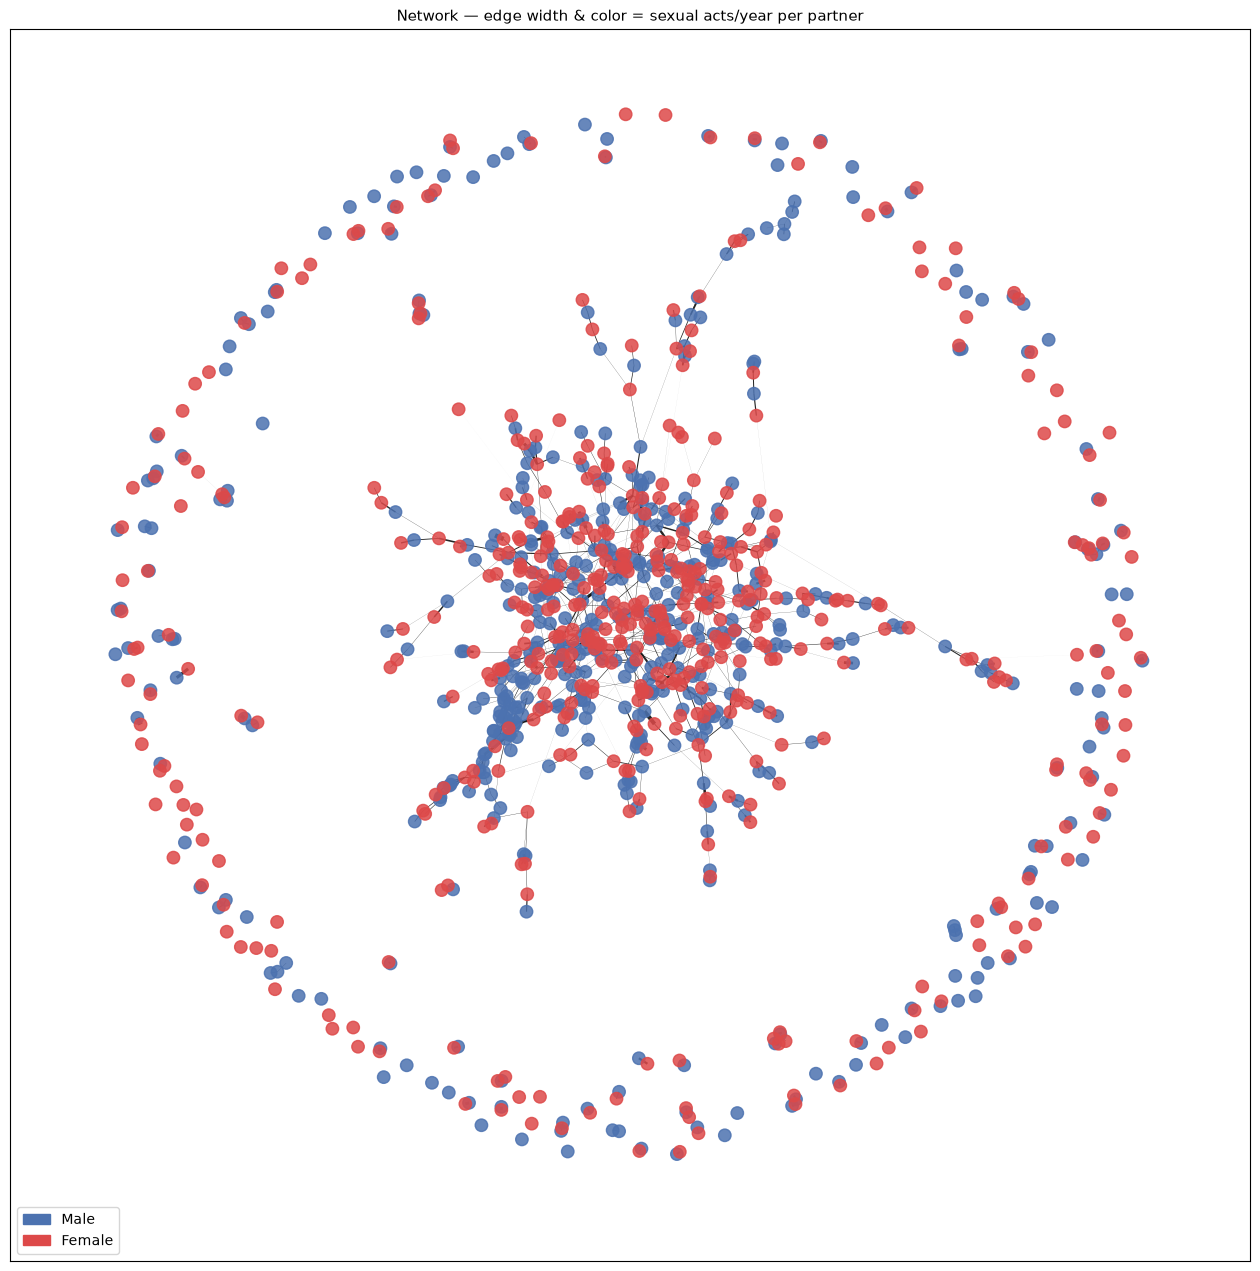

In [188]:
# --- Plot network with edge weights ---
pos = nx.spring_layout(G, seed=None)
colors = ['#4C72B0' if G.nodes[n]['gender'] == 'M' else '#DD4949' for n in G.nodes()]

edge_weights = [d['weight'] for u, v, d in G.edges(data=True)]
max_w = max(edge_weights)
edge_widths = [5 * w / max_w for w in edge_weights]

fig, axes = plt.subplots(1, 1, figsize=(16, 16))

nx.draw_networkx(
    G, pos=pos, ax=axes,
    node_color=colors, node_size=80,
    edge_color="#000000",
    width=edge_widths,
    with_labels=False, alpha=0.85
)
axes.set_title('Network — edge width & color = sexual acts/year per partner', fontsize=11)

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Male'),
    mpatches.Patch(color='#DD4949', label='Female'),
]
axes.legend(handles=legend_handles, loc='lower left')


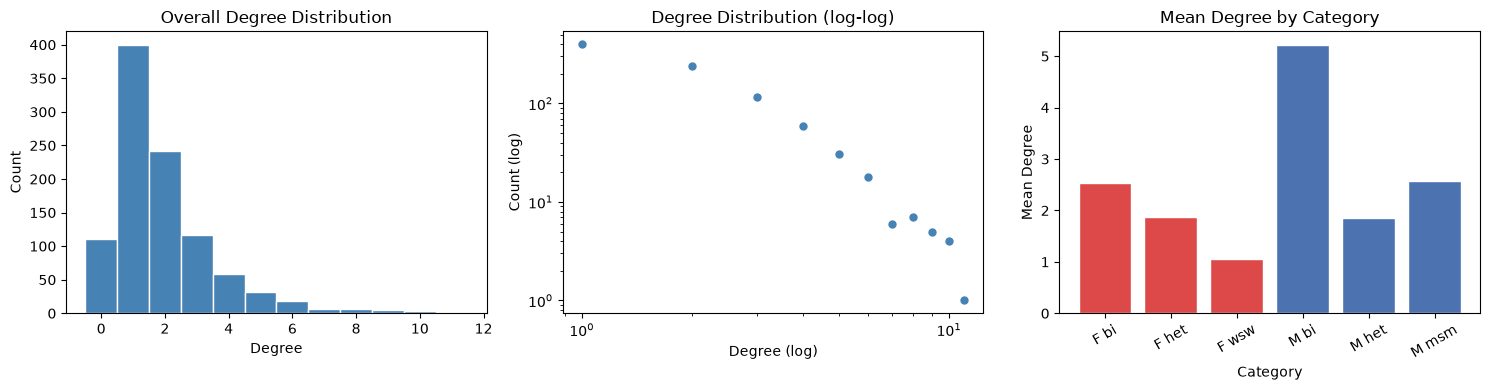

In [189]:
# --- Degree distribution plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

degrees = [d for _, d in G.degree()]

# 1. Overall degree distribution
axes[0].hist(degrees, bins=range(0, max(degrees)+2), color='steelblue', edgecolor='white', align='left')
axes[0].set_title('Overall Degree Distribution')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

# 2. Log-log degree distribution (check power-law from BA)
degree_counts = pd.Series(degrees).value_counts().sort_index()
axes[1].loglog(degree_counts.index, degree_counts.values, 'o', color='steelblue', markersize=5)
axes[1].set_title('Degree Distribution (log-log)')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Count (log)')

# 3. Mean degree by category
mean_deg = achieved.groupby(['gender', 'behavior'])['total'].mean().reset_index()
labels   = [f"{r['gender']} {r['behavior']}" for _, r in mean_deg.iterrows()]
colors_bar = ['#DD4949' if r['gender'] == 'F' else '#4C72B0' for _, r in mean_deg.iterrows()]
axes[2].bar(labels, mean_deg['total'], color=colors_bar, edgecolor='white')
axes[2].set_title('Mean Degree by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Mean Degree')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [191]:
N_ENSEMBLES = 72
N_PER_GROUP = 12  # each group of 12 should sum to total network

# Initialize ensemble graphs with same nodes and attributes
ensembles = []
for k in range(N_ENSEMBLES):
    H = nx.Graph()
    for node, data in G.nodes(data=True):
        H.add_node(node, **data)
    ensembles.append(H)

rng_ens = np.random.default_rng(seed=None)

# For each edge, distribute its weight across 6 groups of 12
for u, v, data in G.edges(data=True):
    total_weight = data['weight']

    if total_weight == 0:
        continue

    # First split into 6 equal-ish groups via random partition
    cuts_outer  = np.sort(rng_ens.uniform(0, total_weight, 6 - 1))
    group_weights = np.diff([0] + list(cuts_outer) + [total_weight])

    for g, gw in enumerate(group_weights):
        if gw == 0:
            continue

        # Split each group weight across 12 ensembles
        cuts_inner = np.sort(rng_ens.uniform(0, gw, N_PER_GROUP - 1))
        parts      = np.diff([0] + list(cuts_inner) + [gw])

        for k, w in enumerate(parts):
            ensemble_idx = g * N_PER_GROUP + k
            if int(round(w)) > 0:
                ensembles[ensemble_idx].add_edge(u, v, weight=int(round(w)))

# Verify: each group of 12 should sum to total weight
print("Verifying weight conservation per group...")
max_err = 0
for u, v, data in G.edges(data=True):
    total = data['weight']
    for g in range(6):
        group_total = sum(
            ensembles[g * N_PER_GROUP + k][u][v]['weight']
            for k in range(N_PER_GROUP)
            if ensembles[g * N_PER_GROUP + k].has_edge(u, v)
        )
        err = abs(group_total - total)
        max_err = max(max_err, err)

print(f"Max weight reconstruction error per group: {max_err:.2f}")

# Summary per group
print(f"\nGroup summary (each group of {N_PER_GROUP} should sum to total network):")
for g in range(6):
    group_edges   = [ensembles[g * N_PER_GROUP + k].number_of_edges() for k in range(N_PER_GROUP)]
    group_weights = [
        sum(d['weight'] for _, _, d in ensembles[g * N_PER_GROUP + k].edges(data=True))
        for k in range(N_PER_GROUP)
    ]
    print(f"  Group {g+1}: "
          f"mean edges/ensemble={np.mean(group_edges):.0f}  "
          f"total weight={sum(group_weights):.0f}  "
          f"(target: {sum(d['weight'] for _, _, d in G.edges(data=True)):.0f})")

Verifying weight conservation per group...
Max weight reconstruction error per group: 168.50

Group summary (each group of 12 should sum to total network):
  Group 1: mean edges/ensemble=149  total weight=2646  (target: 20561)
  Group 2: mean edges/ensemble=140  total weight=2451  (target: 20561)
  Group 3: mean edges/ensemble=145  total weight=2612  (target: 20561)
  Group 4: mean edges/ensemble=153  total weight=2695  (target: 20561)
  Group 5: mean edges/ensemble=151  total weight=2855  (target: 20561)
  Group 6: mean edges/ensemble=145  total weight=2614  (target: 20561)


In [192]:
import os

output_dir = 'ensembles'
os.makedirs(output_dir, exist_ok=True)

for g in range(6):
    for k in range(N_PER_GROUP):
        H    = ensembles[g * N_PER_GROUP + k]
        name = f'G_{g+1}.{k+1}'
        path = os.path.join(output_dir, f'{name}.csv')

        # Save edge list with weights
        edges = [(u, v, d['weight']) for u, v, d in H.edges(data=True)]
        edge_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
        edge_df.to_csv(path, index=False)

print(f"Saved {N_ENSEMBLES} ensemble edge lists to '{output_dir}/'")
print(f"Example files: G_1.1.csv, G_1.2.csv, ... G_6.12.csv")
print(f"\nExample content of G_1.1.csv:")
print(pd.read_csv(os.path.join(output_dir, 'G_1.1.csv')).head())

Saved 72 ensemble edge lists to 'ensembles/'
Example files: G_1.1.csv, G_1.2.csv, ... G_6.12.csv

Example content of G_1.1.csv:
   source  target  weight
0       0     503       3
1       2     786       1
2       3     562       1
3       3     571       1
4      13     880       1
